In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# ================================================
# 0. SETUP
# ================================================
import os
import glob
import shutil
import random
import traceback
import numpy as np
import nibabel as nib
import cv2
import yaml

random.seed(42)

input_dir = '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData'
work_dir  = '/kaggle/working/yolo_dataset'

# Temporary staging folder — we convert everything here first, then split by patient
staging_dir = os.path.join(work_dir, 'staging')
os.makedirs(os.path.join(staging_dir, 'images'), exist_ok=True)
os.makedirs(os.path.join(staging_dir, 'labels'), exist_ok=True)

In [3]:
# ================================================
# 1. THE CONVERSION FUNCTION (multi-modality RGB)
# ================================================
def process_nifti_to_yolo(flair_path, t1ce_path, t2_path, mask_path, output_dir, patient_id):
    """
    Slices FLAIR, T1CE, and T2 volumes, stacks them into an RGB image per slice,
    extracts tumor contours from the mask, and writes YOLO segmentation labels.
    """
    flair = nib.load(flair_path).get_fdata()
    t1ce  = nib.load(t1ce_path).get_fdata()
    t2    = nib.load(t2_path).get_fdata()
    mask  = nib.load(mask_path).get_fdata()

    def norm(slice_2d):
        return cv2.normalize(slice_2d, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    for z in range(flair.shape[2]):
        slice_mask = mask[:, :, z]

        # Skip slices with no tumor to avoid extreme class imbalance
        if np.max(slice_mask) == 0:
            continue

        # Build RGB image: R=FLAIR, G=T1CE, B=T2
        r = norm(flair[:, :, z])
        g = norm(t1ce[:, :, z])
        b = norm(t2[:, :, z])
        rgb_img = cv2.merge([b, g, r])  # OpenCV expects BGR order

        img_filename = f"{patient_id}_slice_{z}.png"
        cv2.imwrite(os.path.join(output_dir, 'images', img_filename), rgb_img)

        # Convert mask to binary 8-bit for contour detection
        binary_mask = (slice_mask > 0).astype(np.uint8) * 255
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        label_filename = f"{patient_id}_slice_{z}.txt"
        with open(os.path.join(output_dir, 'labels', label_filename), 'w') as f:
            for contour in contours:
                coords = []
                for point in contour:
                    x = point[0][0] / flair.shape[1]
                    y = point[0][1] / flair.shape[0]
                    coords.extend([f"{x:.6f}", f"{y:.6f}"])

                # Class ID 0 = "Tumor". Need at least 3 points (6 coords)
                if len(coords) >= 6:
                    f.write("0 " + " ".join(coords) + "\n")

In [4]:
# ================================================
# 2. THE KAGGLE AUTOMATION LOOP (with error handling)
# ================================================
print("Searching for FLAIR scans...")
scan_files = glob.glob(os.path.join(input_dir, '**/*_flair.nii*'), recursive=True)
print(f"Found {len(scan_files)} FLAIR scans. Starting conversion...")

for scan_path in scan_files:
    flair_path = scan_path
    t1ce_path  = scan_path.replace('_flair', '_t1ce')
    t2_path    = scan_path.replace('_flair', '_t2')
    mask_path  = scan_path.replace('_flair', '_seg')

    required = [flair_path, t1ce_path, t2_path, mask_path]
    if not all(os.path.exists(p) for p in required):
        missing = [p for p in required if not os.path.exists(p)]
        print(f"⚠️ Skipping: missing file(s) for {scan_path}: {missing}")
        continue

    if any(os.path.getsize(p) == 0 for p in required):
        print(f"⚠️ Skipping: empty/corrupted file detected at {scan_path}")
        continue

    patient_id = os.path.basename(os.path.dirname(scan_path))

    try:
        print(f"Processing {patient_id}...")
        process_nifti_to_yolo(flair_path, t1ce_path, t2_path, mask_path, staging_dir, patient_id)
    except Exception as e:
        print(f"❌ Error processing {patient_id}. Skipping to next patient. Error: {e}")
        traceback.print_exc()
        continue

print("\nSUCCESS: Finished slicing the entire BraTS dataset!")

Searching for FLAIR scans...
Found 369 FLAIR scans. Starting conversion...
Processing BraTS20_Training_083...
Processing BraTS20_Training_337...
Processing BraTS20_Training_161...
Processing BraTS20_Training_198...
Processing BraTS20_Training_284...
Processing BraTS20_Training_169...
Processing BraTS20_Training_157...
Processing BraTS20_Training_073...
Processing BraTS20_Training_253...
Processing BraTS20_Training_026...
Processing BraTS20_Training_100...
Processing BraTS20_Training_107...
Processing BraTS20_Training_245...
Processing BraTS20_Training_358...
Processing BraTS20_Training_310...
Processing BraTS20_Training_205...
Processing BraTS20_Training_225...
Processing BraTS20_Training_320...
Processing BraTS20_Training_162...
Processing BraTS20_Training_108...
Processing BraTS20_Training_048...
Processing BraTS20_Training_218...
Processing BraTS20_Training_289...
Processing BraTS20_Training_045...
Processing BraTS20_Training_334...
Processing BraTS20_Training_054...
Processing BraT

In [5]:
# ================================================
# 3. PATIENT-LEVEL TRAIN / VAL SPLIT
# ================================================
# Critical: split by PATIENT, not by slice, so slices from the same
# patient don't leak between train and val (which would inflate val accuracy).

all_images = glob.glob(os.path.join(staging_dir, 'images', '*.png'))
print(f"Total slices generated: {len(all_images)}")

# Extract unique patient IDs from filenames like BraTS20_Training_083_slice_75.png
patient_ids = sorted(set(
    os.path.basename(f).split('_slice_')[0] for f in all_images
))
print(f"Total unique patients: {len(patient_ids)}")

random.shuffle(patient_ids)
split_idx = int(len(patient_ids) * 0.8)
train_patients = set(patient_ids[:split_idx])
val_patients   = set(patient_ids[split_idx:])
print(f"Train patients: {len(train_patients)} | Val patients: {len(val_patients)}")

# Create final train/val folder structure
for split in ['train', 'val']:
    os.makedirs(os.path.join(work_dir, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(work_dir, split, 'labels'), exist_ok=True)

moved_train, moved_val, skipped = 0, 0, 0

for img_path in all_images:
    fname = os.path.basename(img_path)
    patient_id = fname.split('_slice_')[0]
    label_path = os.path.join(staging_dir, 'labels', fname.replace('.png', '.txt'))

    if not os.path.exists(label_path):
        skipped += 1
        continue

    split = 'train' if patient_id in train_patients else 'val'
    shutil.copy(img_path, os.path.join(work_dir, split, 'images', fname))
    shutil.copy(label_path, os.path.join(work_dir, split, 'labels', fname.replace('.png', '.txt')))

    if split == 'train':
        moved_train += 1
    else:
        moved_val += 1

print(f"Moved {moved_train} slices to train, {moved_val} slices to val, {skipped} skipped (no label).")

Total slices generated: 24354
Total unique patients: 368
Train patients: 294 | Val patients: 74
Moved 19603 slices to train, 4751 slices to val, 0 skipped (no label).


In [6]:
# ================================================
# 4. DATASET CONFIG (data.yaml)
# ================================================
data_yaml = {
    'train': os.path.join(work_dir, 'train', 'images'),
    'val':   os.path.join(work_dir, 'val', 'images'),
    'nc': 1,
    'names': ['Tumor']
}

yaml_path = '/kaggle/working/data.yaml'
with open(yaml_path, 'w') as outfile:
    yaml.dump(data_yaml, outfile, default_flow_style=False)

print("data.yaml successfully created!")
print(data_yaml)

data.yaml successfully created!
{'train': '/kaggle/working/yolo_dataset/train/images', 'val': '/kaggle/working/yolo_dataset/val/images', 'nc': 1, 'names': ['Tumor']}


In [7]:
# ================================================
# 5. INSTALL ULTRALYTICS
# ================================================
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.4 MB/s eta 0:00:00


In [8]:
# ================================================
# 6. TRAINING
# ================================================
from ultralytics import YOLO

model = YOLO('yolov8m-seg.pt')  # nano seg model — swap to yolov8s-seg.pt/m for more capacity

results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=240,           # BraTS slices are 240x240
    batch=16,
    patience=10,          # early stopping if val doesn't improve
    project='/kaggle/working/runs',
    name='brain_tumor_seg',
    val=True
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015

In [9]:
# ================================================
# 7. EVALUATION
# ================================================
# Load the best checkpoint from training
best_model_path = '/kaggle/working/runs/brain_tumor_seg/weights/best.pt'
best_model = YOLO(best_model_path)

metrics = best_model.val(data=yaml_path, split='val')

print("\n--- Segmentation Metrics ---")
print(f"mAP50 (mask):     {metrics.seg.map50:.4f}")
print(f"mAP50-95 (mask):  {metrics.seg.map:.4f}")
print(f"Precision:        {metrics.seg.mp:.4f}")
print(f"Recall:           {metrics.seg.mr:.4f}")

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv8m-seg summary (fused): 106 layers, 27,222,963 parameters, 0 gradients, 104.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 745.8±117.0 MB/s, size: 24.8 KB)
val: Scanning /kaggle/working/yolo_dataset/val/labels.cache... 4751 images, 63 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4751/4751 1.8Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 297/297 6.4it/s 46.7s
                   all       4751       8494      0.856      0.508      0.568      0.399      0.858      0.495      0.571      0.361
Speed: 0.2ms preprocess, 5.3ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to /kaggle/working/runs/segment/val

--- Segmentation Metrics ---
mAP50 (mask):     0.5711
mAP50-95 (mask):  0.3610
Precision:        0.8580
Recall:           0.4948


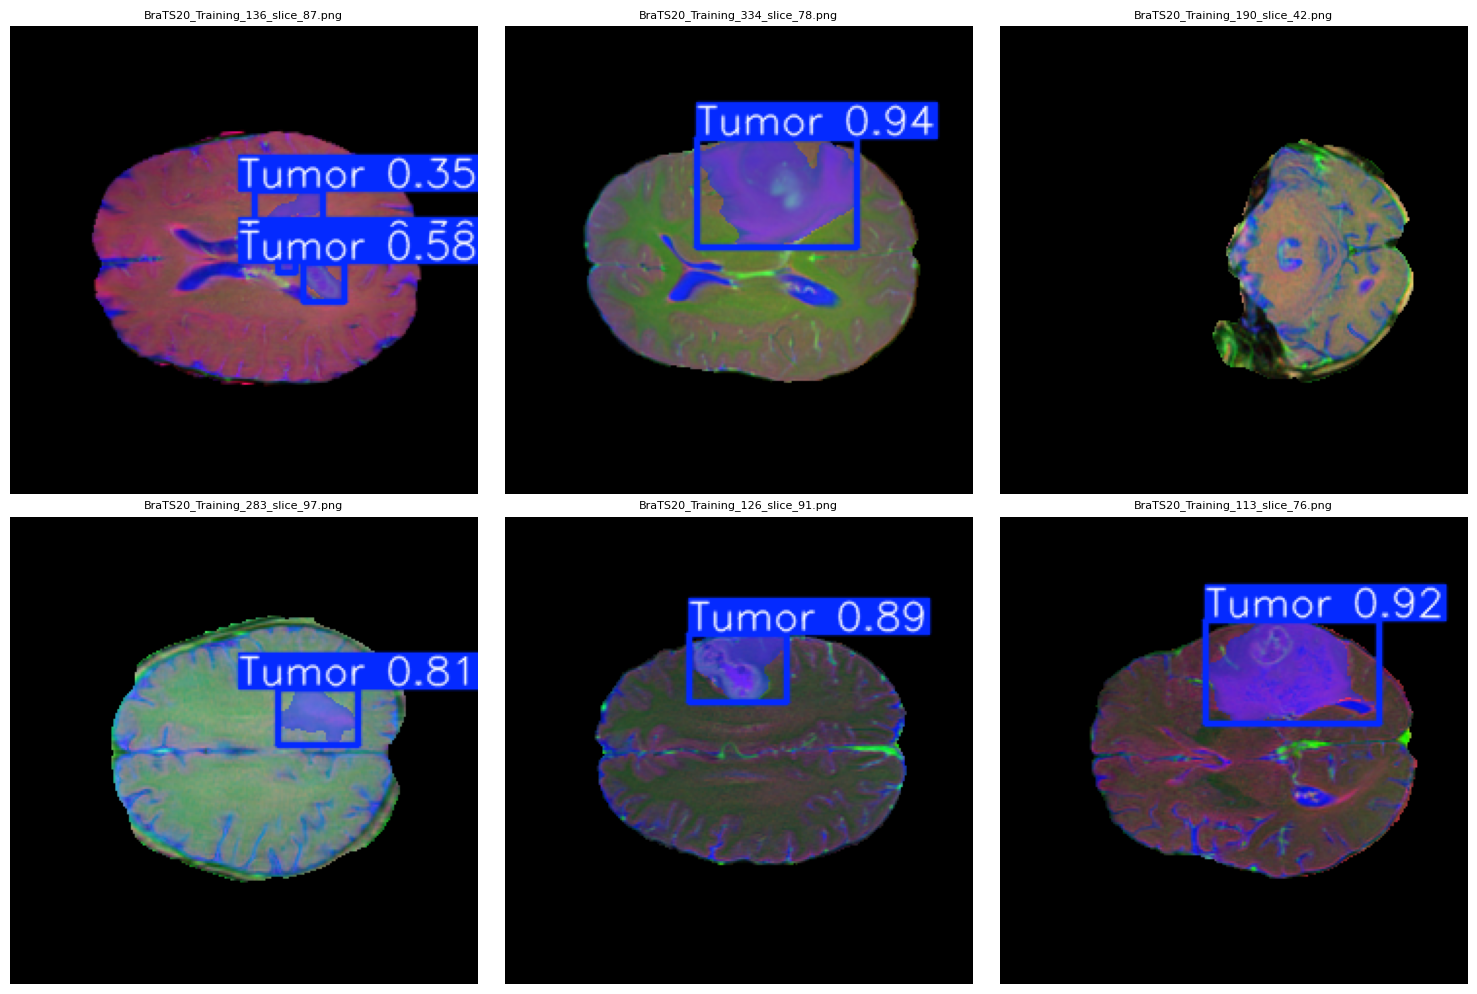

In [10]:
# ================================================
# 8. VISUALIZE PREDICTIONS ON SAMPLE VAL IMAGES
# ================================================
import matplotlib.pyplot as plt

val_images = glob.glob(os.path.join(work_dir, 'val', 'images', '*.png'))
sample_images = random.sample(val_images, min(6, len(val_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, img_path in enumerate(sample_images):
    result = best_model.predict(img_path, conf=0.25, verbose=False)[0]
    annotated = result.plot()  # returns BGR numpy array with masks/boxes drawn
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    axes[i].imshow(annotated_rgb)
    axes[i].set_title(os.path.basename(img_path), fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/sample_predictions.png', dpi=150)
plt.show()

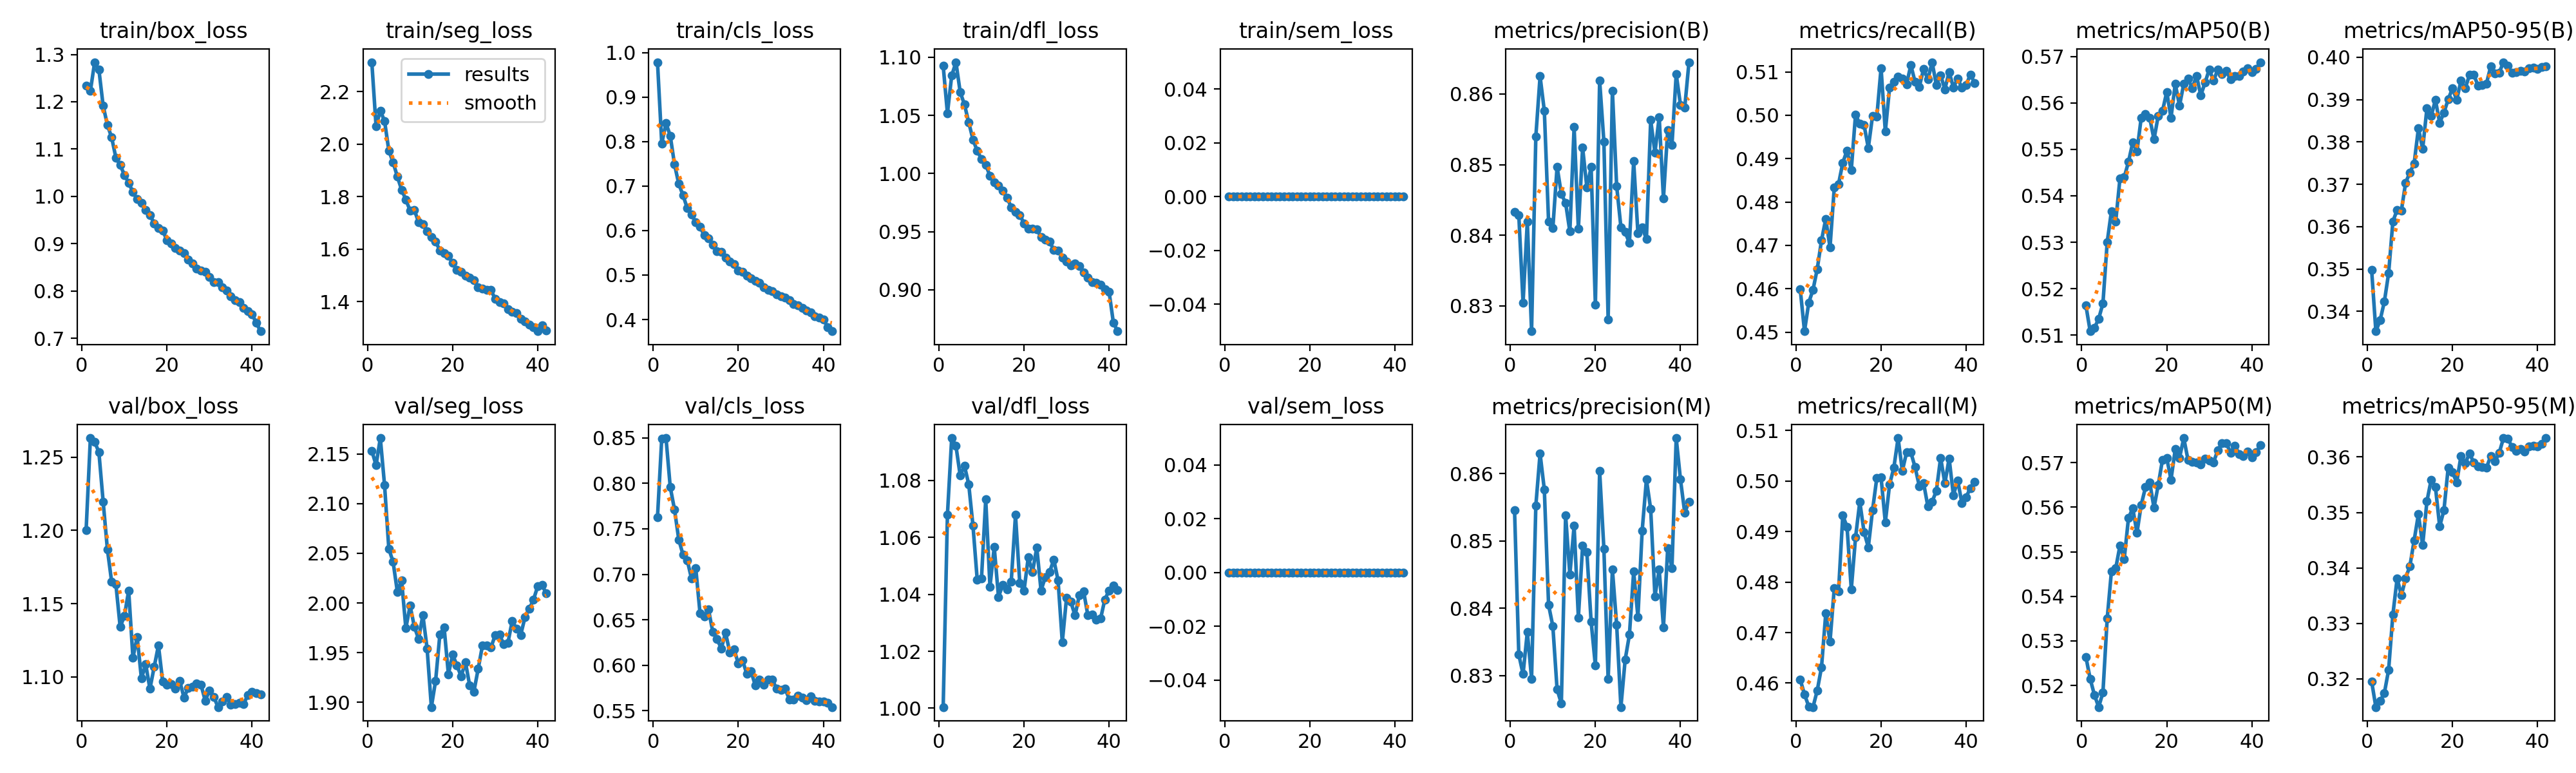

In [11]:
from IPython.display import Image, display
display(Image(filename=glob.glob('/kaggle/working/runs/*/results.png')[0]))

In [12]:
"""
Brain Tumor Segmentation — Model Comparison App
=================================================
Compares 3 models side-by-side on a single MRI slice:
  1. YOLOv8-seg  (Ultralytics)
  2. U-Net        (custom PyTorch checkpoint)
  3. Attention U-Net (custom PyTorch checkpoint)

Run locally with:
    pip install gradio torch torchvision ultralytics opencv-python pillow numpy
    python compare_models_app.py

Then open the local URL Gradio prints (usually http://127.0.0.1:7860)

--------------------------------------------------------------------
BEFORE RUNNING — EDIT THE CONFIG SECTION BELOW:
  - Point YOLO_WEIGHTS to your best.pt
  - Point UNET_WEIGHTS / ATTN_UNET_WEIGHTS to your trained .pth files
  - If your U-Net / Attention U-Net class definitions differ from the
    ones below (different depth, channels, etc.), replace them with
    your actual training-time model classes so the state_dict loads
    correctly. The architecture MUST match what you trained.
--------------------------------------------------------------------
"""
import gradio as gr
import nest_asyncio

# 1. Close any lingering background Gradio servers
gr.close_all()

# 2. Patch the asyncio event loop to play nicely with Jupyter
nest_asyncio.apply()

# ... [The rest of your imports and code go here] ...
import os
import numpy as np
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

import gradio as gr

# ============================================================
# CONFIG — EDIT THESE PATHS
# ============================================================
YOLO_WEIGHTS = "/kaggle/input/models/cmdcrypto/compare-model/tensorflow2/default/1/best_1.pt"              # your trained YOLO seg checkpoint
UNET_WEIGHTS = "/kaggle/input/models/cmdcrypto/compare-model/tensorflow2/default/1/best_attention_unet.h5"             # your trained plain U-Net checkpoint
ATTN_UNET_WEIGHTS = "/kaggle/input/models/cmdcrypto/compare-model/tensorflow2/default/1/best_unet.h5"   # your trained Attention U-Net checkpoint

IMG_SIZE = 240          # match training image size
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# ============================================================
# MODEL DEFINITIONS
# NOTE: these must match the exact architecture you trained with.
# If yours differs, swap these classes out before loading weights.
# ============================================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    """Standard U-Net, 3-channel input, 1-channel output (sigmoid)."""

    def __init__(self, in_ch=3, out_ch=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base * 8, base * 16)

        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)

        self.out_conv = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return torch.sigmoid(self.out_conv(d1))


class AttentionGate(nn.Module):
    def __init__(self, gate_ch, skip_ch, inter_ch):
        super().__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(gate_ch, inter_ch, 1), nn.BatchNorm2d(inter_ch)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(skip_ch, inter_ch, 1), nn.BatchNorm2d(inter_ch)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, 1), nn.BatchNorm2d(1), nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


class AttentionUNet(nn.Module):
    """U-Net with attention gates on the skip connections."""

    def __init__(self, in_ch=3, out_ch=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base * 8, base * 16)

        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.att4 = AttentionGate(base * 8, base * 8, base * 4)
        self.dec4 = DoubleConv(base * 16, base * 8)

        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.att3 = AttentionGate(base * 4, base * 4, base * 2)
        self.dec3 = DoubleConv(base * 8, base * 4)

        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.att2 = AttentionGate(base * 2, base * 2, base)
        self.dec2 = DoubleConv(base * 4, base * 2)

        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.att1 = AttentionGate(base, base, base // 2)
        self.dec1 = DoubleConv(base * 2, base)

        self.out_conv = nn.Conv2d(base, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        e4a = self.att4(d4, e4)
        d4 = self.dec4(torch.cat([d4, e4a], dim=1))

        d3 = self.up3(d4)
        e3a = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3a], dim=1))

        d2 = self.up2(d3)
        e2a = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2a], dim=1))

        d1 = self.up1(d2)
        e1a = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1a], dim=1))

        return torch.sigmoid(self.out_conv(d1))


# ============================================================
# LOAD MODELS (lazy — only loads if weight file exists)
# ============================================================
yolo_model = None
unet_model = None
attn_unet_model = None

def try_load_yolo():
    global yolo_model
    if yolo_model is not None:
        return yolo_model
    if not os.path.exists(YOLO_WEIGHTS):
        return None
    from ultralytics import YOLO
    yolo_model = YOLO(YOLO_WEIGHTS)
    return yolo_model


def try_load_unet():
    global unet_model
    if unet_model is not None:
        return unet_model
    if not os.path.exists(UNET_WEIGHTS):
        return None
    
    m = UNet().to(DEVICE)
    # THE FIX: Add weights_only=False right here
    ckpt = torch.load(UNET_WEIGHTS, map_location=DEVICE, weights_only=False)
    
    # Handle if the checkpoint is a dict with a 'state_dict' key
    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        ckpt = ckpt["state_dict"]
        
    m.load_state_dict(ckpt)
    m.eval()
    unet_model = m
    return unet_model

def try_load_attn_unet():
    global attn_unet_model
    if attn_unet_model is not None:
        return attn_unet_model
    if not os.path.exists(ATTN_UNET_WEIGHTS):
        return None
        
    m = AttentionUNet().to(DEVICE)
    # THE FIX: Add weights_only=False right here
    ckpt = torch.load(ATTN_UNET_WEIGHTS, map_location=DEVICE, weights_only=False)
    
    if isinstance(ckpt, dict) and "state_dict" in ckpt:
        ckpt = ckpt["state_dict"]
        
    m.load_state_dict(ckpt)
    m.eval()
    attn_unet_model = m
    return attn_unet_model

# ============================================================
# INFERENCE HELPERS
# ============================================================
def preprocess_for_torch(pil_img):
    img = pil_img.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img).astype(np.float32) / 255.0
    tensor = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(DEVICE)
    return tensor, img


def overlay_mask(pil_img, mask, color=(255, 0, 0), alpha=0.45):
    """mask: 2D numpy array of 0/1, same size as pil_img (or resized)."""
    base = np.array(pil_img.convert("RGB").resize((IMG_SIZE, IMG_SIZE)))
    overlay = base.copy()
    overlay[mask > 0] = color
    blended = cv2.addWeighted(overlay, alpha, base, 1 - alpha, 0)
    return Image.fromarray(blended)


def dice_score(pred, gt, eps=1e-6):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    return (2 * inter + eps) / (pred.sum() + gt.sum() + eps)


def iou_score(pred, gt, eps=1e-6):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    inter = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()
    return (inter + eps) / (union + eps)


def run_yolo(pil_img):
    model = try_load_yolo()
    if model is None:
        return None, "YOLO weights not found — set YOLO_WEIGHTS path."
    resized = pil_img.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    result = model.predict(np.array(resized), conf=0.25, verbose=False)[0]
    mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    if result.masks is not None:
        for m in result.masks.data.cpu().numpy():
            m_resized = cv2.resize(m, (IMG_SIZE, IMG_SIZE))
            mask = np.maximum(mask, (m_resized > 0.5).astype(np.uint8))
    return mask, None


def run_torch_model(pil_img, model):
    if model is None:
        return None, "Weights not found — set the correct path in CONFIG."
    tensor, _ = preprocess_for_torch(pil_img)
    with torch.no_grad():
        pred = model(tensor)
    mask = (pred.squeeze().cpu().numpy() > 0.5).astype(np.uint8)
    return mask, None


# ============================================================
# MAIN COMPARISON FUNCTION (called by Gradio UI)
# ============================================================
def compare_models(image, ground_truth_mask):
    if image is None:
        return None, None, None, "Upload an MRI slice first."

    results_imgs = []
    metrics_lines = []

    gt_mask_np = None
    if ground_truth_mask is not None:
        gt = ground_truth_mask.convert("L").resize((IMG_SIZE, IMG_SIZE))
        gt_mask_np = (np.array(gt) > 127).astype(np.uint8)

    # --- YOLO ---
    yolo_mask, yolo_err = run_yolo(image)
    if yolo_mask is not None:
        results_imgs.append(overlay_mask(image, yolo_mask, color=(255, 60, 60)))
        line = "YOLOv8-seg: "
        if gt_mask_np is not None:
            line += f"Dice={dice_score(yolo_mask, gt_mask_np):.3f}  IoU={iou_score(yolo_mask, gt_mask_np):.3f}"
        else:
            line += f"tumor pixels={int(yolo_mask.sum())}"
        metrics_lines.append(line)
    else:
        results_imgs.append(image)
        metrics_lines.append(f"YOLOv8-seg: {yolo_err}")

    # --- U-Net ---
    unet = try_load_unet()
    unet_mask, unet_err = run_torch_model(image, unet)
    if unet_mask is not None:
        results_imgs.append(overlay_mask(image, unet_mask, color=(60, 255, 60)))
        line = "U-Net: "
        if gt_mask_np is not None:
            line += f"Dice={dice_score(unet_mask, gt_mask_np):.3f}  IoU={iou_score(unet_mask, gt_mask_np):.3f}"
        else:
            line += f"tumor pixels={int(unet_mask.sum())}"
        metrics_lines.append(line)
    else:
        results_imgs.append(image)
        metrics_lines.append(f"U-Net: {unet_err}")

    # --- Attention U-Net ---
    attn_unet = try_load_attn_unet()
    attn_mask, attn_err = run_torch_model(image, attn_unet)
    if attn_mask is not None:
        results_imgs.append(overlay_mask(image, attn_mask, color=(60, 60, 255)))
        line = "Attention U-Net: "
        if gt_mask_np is not None:
            line += f"Dice={dice_score(attn_mask, gt_mask_np):.3f}  IoU={iou_score(attn_mask, gt_mask_np):.3f}"
        else:
            line += f"tumor pixels={int(attn_mask.sum())}"
        metrics_lines.append(line)
    else:
        results_imgs.append(image)
        metrics_lines.append(f"Attention U-Net: {attn_err}")

    metrics_text = "\n".join(metrics_lines)
    return results_imgs[0], results_imgs[1], results_imgs[2], metrics_text


# ============================================================
# GRADIO UI
# ============================================================
with gr.Blocks(title="Brain Tumor Segmentation — Model Comparison") as demo:
    gr.Markdown("# 🧠 Brain Tumor Segmentation — Model Comparison")
    gr.Markdown(
        "Upload an MRI slice (ideally the same RGB-stacked FLAIR/T1CE/T2 format "
        "used in training) and optionally a ground-truth mask to compute Dice/IoU."
    )

    with gr.Row():
        input_img = gr.Image(type="pil", label="MRI Slice")
        gt_img = gr.Image(type="pil", label="Ground Truth Mask (optional)")

    run_btn = gr.Button("Compare Models", variant="primary")

    with gr.Row():
        yolo_out = gr.Image(label="YOLOv8-seg")
        unet_out = gr.Image(label="U-Net")
        attn_out = gr.Image(label="Attention U-Net")

    metrics_out = gr.Textbox(label="Metrics", lines=4)

    run_btn.click(
        fn=compare_models,
        inputs=[input_img, gt_img],
        outputs=[yolo_out, unet_out, attn_out, metrics_out],
    )

if __name__ == "__main__":
    demo.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://fa373c874afb20bead.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
